# VSE Quantitative Analysis

**Goal:** Vascular Super-Enhancement (VSE) increases contrast between vasculature
and surrounding tissue without degrading image quality.

This notebook evaluates two claims:
1. **CNR is improved** — VSE increases contrast-to-noise ratio between vessels (Ao, IVS, PA) and background tissue.
2. **SNR is preserved** — VSE does not degrade signal-to-noise ratio in any region.

In [132]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Patch

NOTEBOOK_DIR = Path.home() / "vascular-superenhancement-4d-flow" / "notebooks" / "analysis" / "VSE_quantitative_analysis"
CSV_PATH = NOTEBOOK_DIR / "consolidated.csv"

# ── Global plot theme (edit this cell to restyle all figures) ──
COLORS = {"normal": "#5B8EC9", "vse": "#E8855E"}
LABELS = {"normal": "Baseline", "vse": "Enhanced"}

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.3,
    "grid.linewidth": 0.5,
})

BOXPLOT_KW = dict(
    patch_artist=True,
    showmeans=True,
    meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="#333",
                   markersize=5, zorder=5),
    boxprops=dict(linewidth=1.2, edgecolor="#333"),
    whiskerprops=dict(linewidth=1.0, linestyle="-"),
    capprops=dict(linewidth=1.0),
    medianprops=dict(color="#2d2d2d", linewidth=1.5),
    flierprops=dict(marker="o", markerfacecolor="none", markeredgecolor="#888",
                    markersize=5, alpha=0.7),
)

def color_boxes(bp, colors):
    """Apply face colors to box plot patches."""
    for box, c in zip(bp["boxes"], colors):
        box.set_facecolor(c)
        box.set_alpha(0.85)

LEGEND_HANDLES = [
    Patch(facecolor=COLORS["normal"], edgecolor="#333", alpha=0.85, label=LABELS["normal"]),
    Patch(facecolor=COLORS["vse"], edgecolor="#333", alpha=0.85, label=LABELS["vse"]),
]

data = pd.read_csv(CSV_PATH)
print(f"{len(data)} rows  |  {data['patient'].nunique()} patients  |  "
      f"{sorted(data['region'].unique())}  |  {sorted(data['reconstruction'].unique())}")
data.head()

2680 rows  |  17 patients  |  ['Ao', 'Background', 'IVS', 'PA']  |  ['normal', 'vse']


,patient,region,reconstruction,timepoint,mean,std,snr
0,Balboloop,Ao,normal,1,1452.38,67.66,21.465859
1,Balboloop,Ao,normal,2,1399.85,80.98,17.286367
2,Balboloop,Ao,normal,3,1329.10,85.26,15.588787
3,Balboloop,Ao,normal,4,1279.85,55.08,23.236202
4,Balboloop,Ao,normal,5,1234.62,34.42,35.869262


## Data cleaning

Drop timepoints with anomalous SNR (> 100). The 99.5th percentile of SNR across
the dataset is ~54; all 6 values above 100 come from Golotag/PA/vse timepoints 4–9
where the viewer reported near-zero std (confirmed on re-inspection — likely the ROI
overlapping a very homogeneous patch during those cardiac phases).

In [133]:
SNR_OUTLIER_THRESHOLD = 100

outlier_mask = data["snr"] > SNR_OUTLIER_THRESHOLD
n_dropped = outlier_mask.sum()

if n_dropped:
    print(f"Dropping {n_dropped} timepoints with SNR > {SNR_OUTLIER_THRESHOLD}:")
    print(data[outlier_mask][["patient", "region", "reconstruction", "timepoint", "std", "snr"]].to_string(index=False))
else:
    print("No SNR outliers detected.")

data = data[~outlier_mask].reset_index(drop=True)
print(f"\n{len(data)} rows remaining")

Dropping 6 timepoints with SNR > 100:
patient region reconstruction  timepoint   std          snr
Golotag     PA            vse          4 13.00   602.797692
Golotag     PA            vse          5  0.45 17497.600000
Golotag     PA            vse          6 31.99   247.660519
Golotag     PA            vse          7 55.00   143.376545
Golotag     PA            vse          8 34.83   222.321849
Golotag     PA            vse          9 41.59   187.152200

2674 rows remaining


## Derived metrics

Compute time-averaged SNR and CNR for downstream analyses.

In [134]:
regions = sorted(data["region"].unique())
vessel_regions = [r for r in regions if r != "Background"]
cnr_regions = ["Ao", "PA"]  # CNR only meaningful for vascular lumen, not IVS

# --- Time-averaged SNR per (patient, region, reconstruction) ---
snr_avg = (
    data.groupby(["patient", "region", "reconstruction"])["snr"]
    .mean()
    .reset_index()
    .rename(columns={"snr": "snr_mean"})
)

snr_pivot = snr_avg.pivot_table(
    index=["patient", "region"],
    columns="reconstruction",
    values="snr_mean",
)
snr_pivot["vse_minus_normal"] = snr_pivot["vse"] - snr_pivot["normal"]
snr_pivot["vse_over_normal"] = snr_pivot["vse"] / snr_pivot["normal"]

# --- CNR_air: (mean_vessel - mean_air) / std_air ---
air = data[data["region"] == "Background"][["patient", "reconstruction", "timepoint", "mean", "std"]].rename(
    columns={"mean": "air_mean", "std": "air_std"}
)
vessels = data[data["region"].isin(cnr_regions)].copy()
cnr_air_data = vessels.merge(air, on=["patient", "reconstruction", "timepoint"], how="inner")
cnr_air_data["cnr"] = (cnr_air_data["mean"] - cnr_air_data["air_mean"]) / cnr_air_data["air_std"]

cnr_air_avg = (
    cnr_air_data.groupby(["patient", "region", "reconstruction"])["cnr"]
    .mean().reset_index().rename(columns={"cnr": "cnr_mean"})
)
cnr_air_pivot = cnr_air_avg.pivot_table(index=["patient", "region"], columns="reconstruction", values="cnr_mean")
cnr_air_pivot["vse_minus_normal"] = cnr_air_pivot["vse"] - cnr_air_pivot["normal"]
cnr_air_pivot["vse_over_normal"] = cnr_air_pivot["vse"] / cnr_air_pivot["normal"]

# --- CNR_myo: (mean_vessel - mean_IVS) / std_IVS ---
ivs = data[data["region"] == "IVS"][["patient", "reconstruction", "timepoint", "mean", "std"]].rename(
    columns={"mean": "ivs_mean", "std": "ivs_std"}
)
cnr_myo_data = vessels.merge(ivs, on=["patient", "reconstruction", "timepoint"], how="inner")
cnr_myo_data["cnr"] = (cnr_myo_data["mean"] - cnr_myo_data["ivs_mean"]) / cnr_myo_data["ivs_std"]

cnr_myo_avg = (
    cnr_myo_data.groupby(["patient", "region", "reconstruction"])["cnr"]
    .mean().reset_index().rename(columns={"cnr": "cnr_mean"})
)
cnr_myo_pivot = cnr_myo_avg.pivot_table(index=["patient", "region"], columns="reconstruction", values="cnr_mean")
cnr_myo_pivot["vse_minus_normal"] = cnr_myo_pivot["vse"] - cnr_myo_pivot["normal"]
cnr_myo_pivot["vse_over_normal"] = cnr_myo_pivot["vse"] / cnr_myo_pivot["normal"]

# --- Time-averaged mean SI ---
si_avg = (
    data.groupby(["patient", "region", "reconstruction"])["mean"]
    .mean()
    .reset_index()
    .rename(columns={"mean": "si_mean"})
)

print(f"SNR: {len(snr_avg)} entries  |  CNR_air: {len(cnr_air_avg)}, CNR_myo: {len(cnr_myo_avg)} entries  |  SI: {len(si_avg)} entries")

SNR: 134 entries  |  CNR_air: 66, CNR_myo: 66 entries  |  SI: 134 entries


In [135]:
from scipy import stats as sp_stats

def _paired_stats(pivot_df, metric_name, region_list=None):
    """Run paired tests for each region and return a summary DataFrame."""
    if region_list is None:
        region_list = cnr_regions
    rows = []
    for region in region_list:
        pdf = pivot_df.reset_index()
        sub = pdf[pdf["region"] == region].dropna(subset=["normal", "vse"])
        normal = sub["normal"].values
        vse = sub["vse"].values
        diff = vse - normal
        n = len(diff)

        shapiro_stat, shapiro_p = sp_stats.shapiro(diff)
        wilcoxon_stat, wilcoxon_p = sp_stats.wilcoxon(diff)
        ttest_stat, ttest_p = sp_stats.ttest_rel(vse, normal)
        cohens_d = diff.mean() / diff.std()

        rows.append({
            "metric": metric_name,
            "region": region,
            "n": n,
            "normal_mean": normal.mean(),
            "vse_mean": vse.mean(),
            "diff_mean": diff.mean(),
            "diff_std": diff.std(),
            "shapiro_p": shapiro_p,
            "wilcoxon_p": wilcoxon_p,
            "ttest_p": ttest_p,
            "cohens_d": cohens_d,
        })
    return pd.DataFrame(rows)

def _sig(p):
    if p < 0.001: return "***"
    if p < 0.01: return "**"
    if p < 0.05: return "*"
    return "ns"

stats_results = pd.concat([
    _paired_stats(cnr_air_pivot, "CNR_air"),
    _paired_stats(cnr_myo_pivot, "CNR_myo"),
    _paired_stats(snr_pivot, "SNR", region_list=cnr_regions),
], ignore_index=True)

stats_results["wilcoxon_sig"] = stats_results["wilcoxon_p"].apply(_sig)

def _get_sig(metric, region):
    """Look up the Wilcoxon significance string for a metric/region."""
    row = stats_results[(stats_results["metric"] == metric) & (stats_results["region"] == region)]
    p = row["wilcoxon_p"].values[0]
    sig = row["wilcoxon_sig"].values[0]
    return p, sig

print("Stats computed for", len(stats_results), "metric-region combos")

Stats computed for 6 metric-region combos


---

# 1. Primary result: VSE improves vascular contrast (CNR)

Two CNR definitions are compared:
- **CNR_air** = (mean_vessel − mean_air) / std_air
- **CNR_myo** = (mean_vessel − mean_IVS) / std_IVS

CNR_myo is the more clinically relevant metric — it measures contrast between the
blood pool and adjacent myocardium, normalized by myocardial noise.

### 1a. CNR distribution: Baseline vs. Enhanced (both definitions)

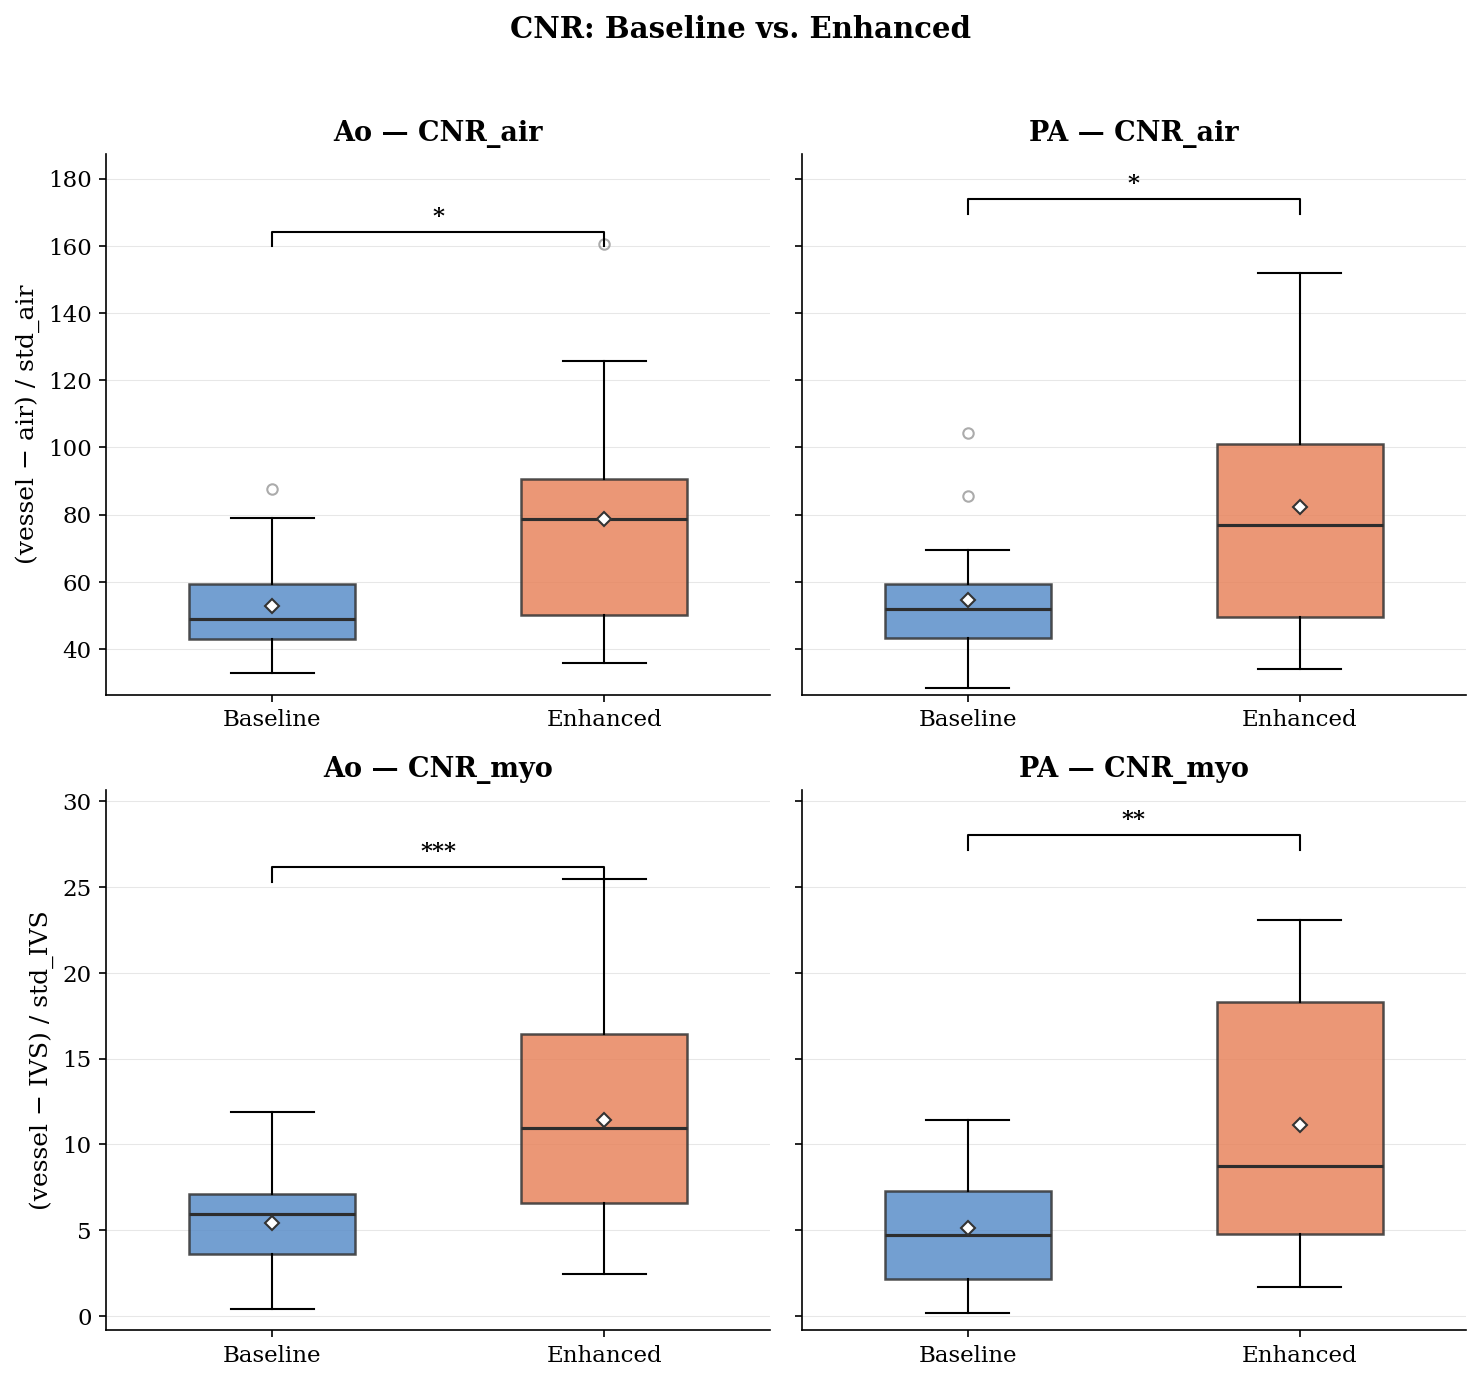

In [136]:
def _annotate_sig(ax, p, sig, x0=0, x1=1):
    """Draw a significance bracket (only if significant)."""
    if sig == "ns":
        return
    ylim = ax.get_ylim()
    y = ylim[1] - (ylim[1] - ylim[0]) * 0.02
    h = (ylim[1] - ylim[0]) * 0.03
    ax.plot([x0, x0, x1, x1], [y - h, y, y, y - h], color="black", linewidth=1.0)
    ax.text((x0 + x1) / 2, y + h * 0.3, sig, ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.set_ylim(ylim[0], y + h * 3)

fig, axes = plt.subplots(2, len(cnr_regions), figsize=(5 * len(cnr_regions), 9), sharey="row")

for j, region in enumerate(cnr_regions):
    for i, (avg_df, label) in enumerate([(cnr_air_avg, "CNR_air"), (cnr_myo_avg, "CNR_myo")]):
        ax = axes[i, j]
        subset = avg_df[avg_df["region"] == region]
        normal = subset[subset["reconstruction"] == "normal"]["cnr_mean"]
        vse = subset[subset["reconstruction"] == "vse"]["cnr_mean"]

        bp = ax.boxplot([normal, vse], positions=[0, 1], widths=0.5, **BOXPLOT_KW)
        color_boxes(bp, [COLORS["normal"], COLORS["vse"]])

        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Baseline", "Enhanced"])
        ax.set_title(f"{region} — {label}", fontweight="bold")

        p, sig = _get_sig(label, region)
        _annotate_sig(ax, p, sig)

    axes[0, 0].set_ylabel("(vessel − air) / std_air")
    axes[1, 0].set_ylabel("(vessel − IVS) / std_IVS")

fig.suptitle("CNR: Baseline vs. Enhanced", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

### 1a (alt). CNR and SNR side by side

CNR_air and CNR_myo each shown with SNR for context.

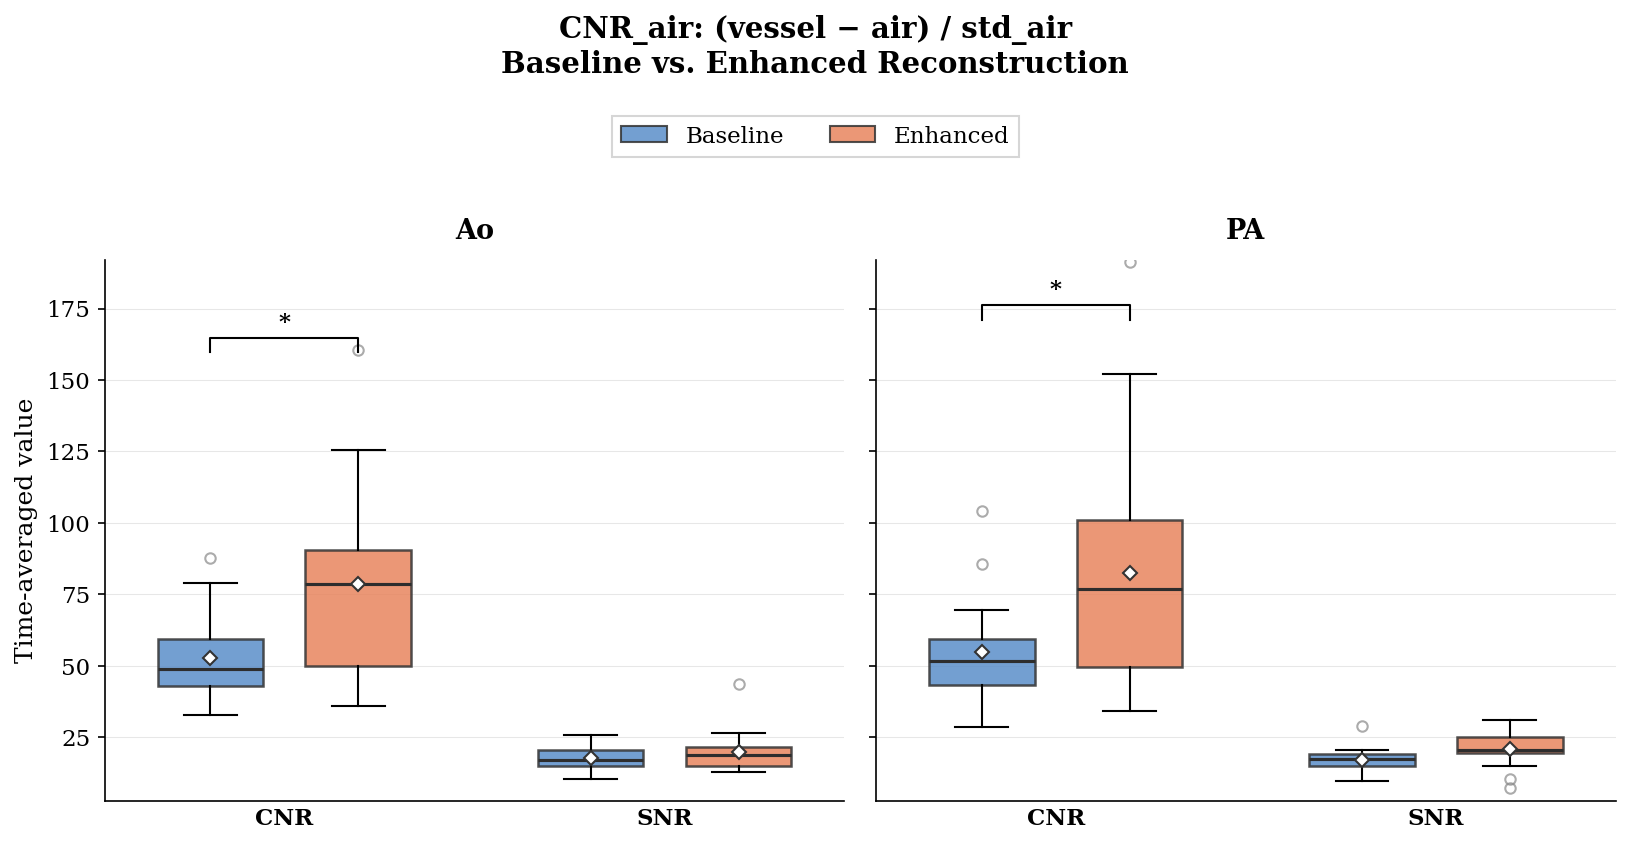

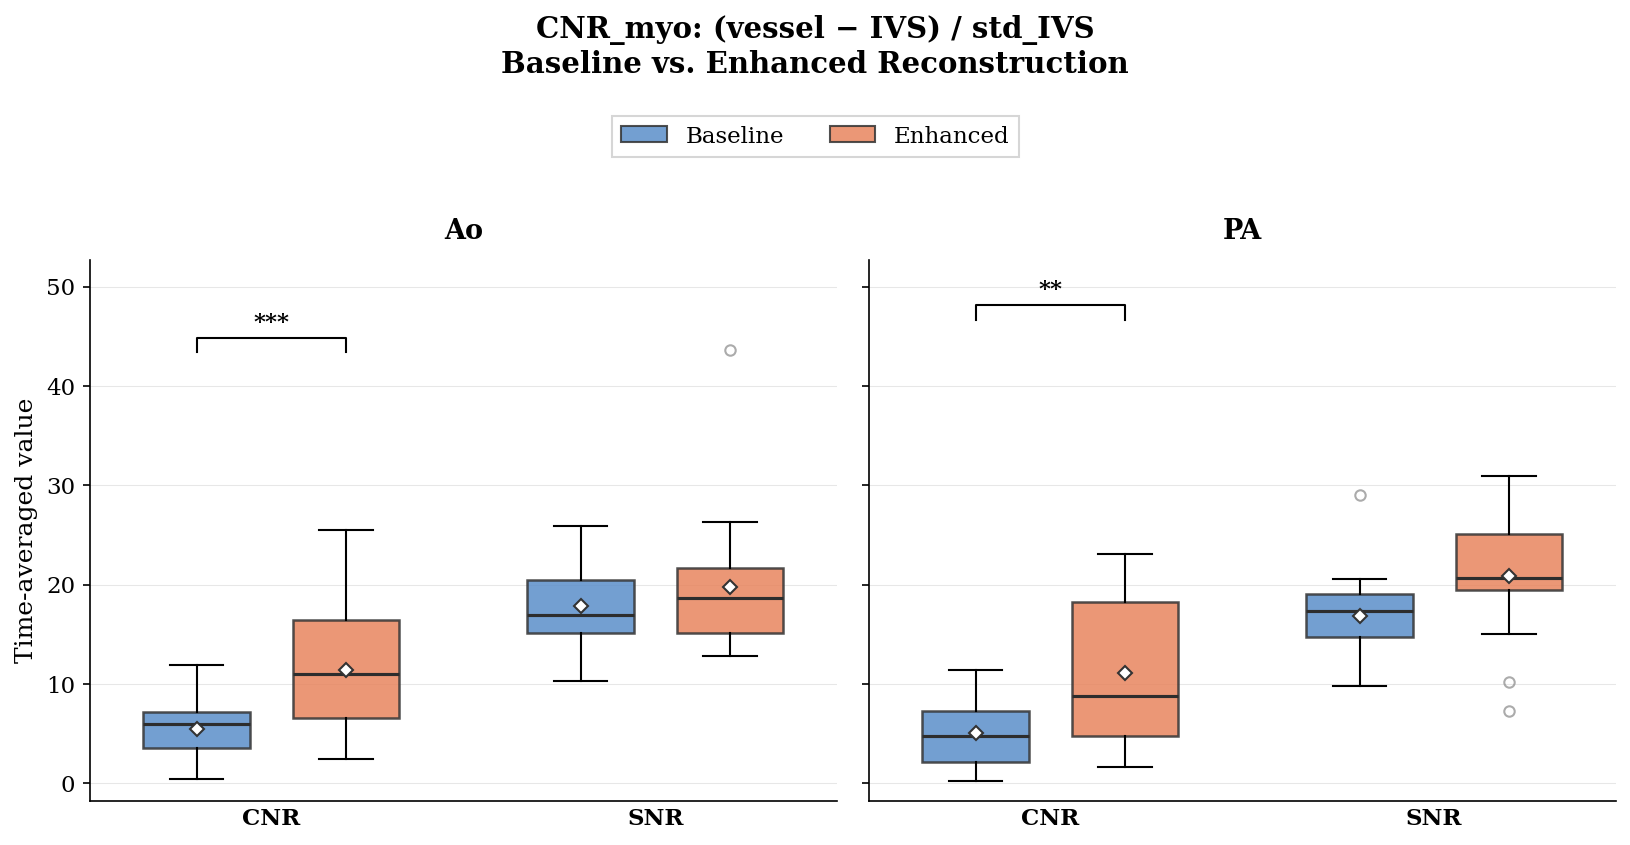

In [137]:
def _get_nv(df, region, col):
    """Return (baseline_values, enhanced_values) for a region."""
    sub = df[df["region"] == region]
    return (sub[sub["reconstruction"] == "normal"][col],
            sub[sub["reconstruction"] == "vse"][col])

for cnr_label, cnr_avg_df, metric_key in [
    ("CNR_air: (vessel − air) / std_air", cnr_air_avg, "CNR_air"),
    ("CNR_myo: (vessel − IVS) / std_IVS", cnr_myo_avg, "CNR_myo"),
]:
    fig, axes = plt.subplots(1, len(cnr_regions), figsize=(5.5 * len(cnr_regions), 5), sharey=True)

    for ax, region in zip(axes, cnr_regions):
        cnr_n, cnr_v = _get_nv(cnr_avg_df, region, "cnr_mean")
        snr_n, snr_v = _get_nv(snr_avg, region, "snr_mean")

        bp = ax.boxplot(
            [cnr_n, cnr_v, snr_n, snr_v],
            positions=[0, 0.7, 1.8, 2.5],
            widths=0.5,
            **BOXPLOT_KW,
        )
        color_boxes(bp, [COLORS["normal"], COLORS["vse"]] * 2)

        ax.set_xticks([0.35, 2.15])
        ax.set_xticklabels(["CNR", "SNR"], fontweight="bold")
        ax.set_title(region, fontweight="bold", pad=10)
        ax.tick_params(axis="x", length=0)

        p, sig = _get_sig(metric_key, region)
        _annotate_sig(ax, p, sig, x0=0, x1=0.7)
        p_snr, sig_snr = _get_sig("SNR", region)
        _annotate_sig(ax, p_snr, sig_snr, x0=1.8, x1=2.5)

    axes[0].set_ylabel("Time-averaged value")
    fig.legend(handles=LEGEND_HANDLES, loc="upper center", ncol=2,
               frameon=True, fancybox=False, edgecolor="#ccc",
               fontsize=11, bbox_to_anchor=(0.5, 1.0))
    fig.suptitle(f"{cnr_label}\nBaseline vs. Enhanced Reconstruction",
                 fontsize=14, fontweight="bold", y=1.12)
    fig.tight_layout()
    plt.show()

### 1b. Paired patient-level plots: Baseline → Enhanced

Each line connects one patient's time-averaged value under Baseline (left) to Enhanced (right).
Green = improved; red = decreased. Patient labels shown for cases that decreased.

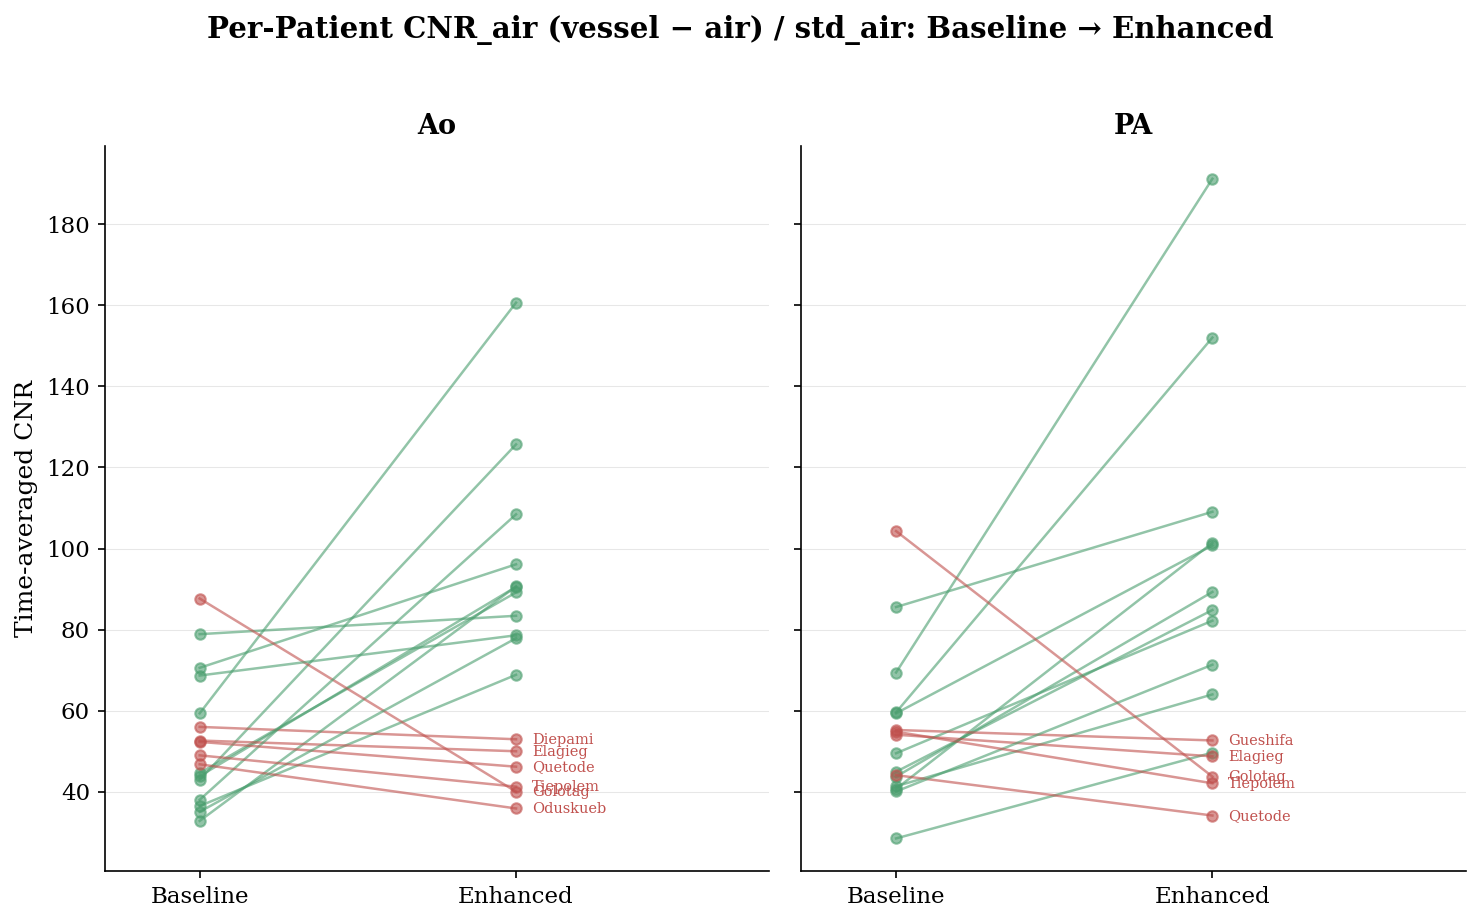

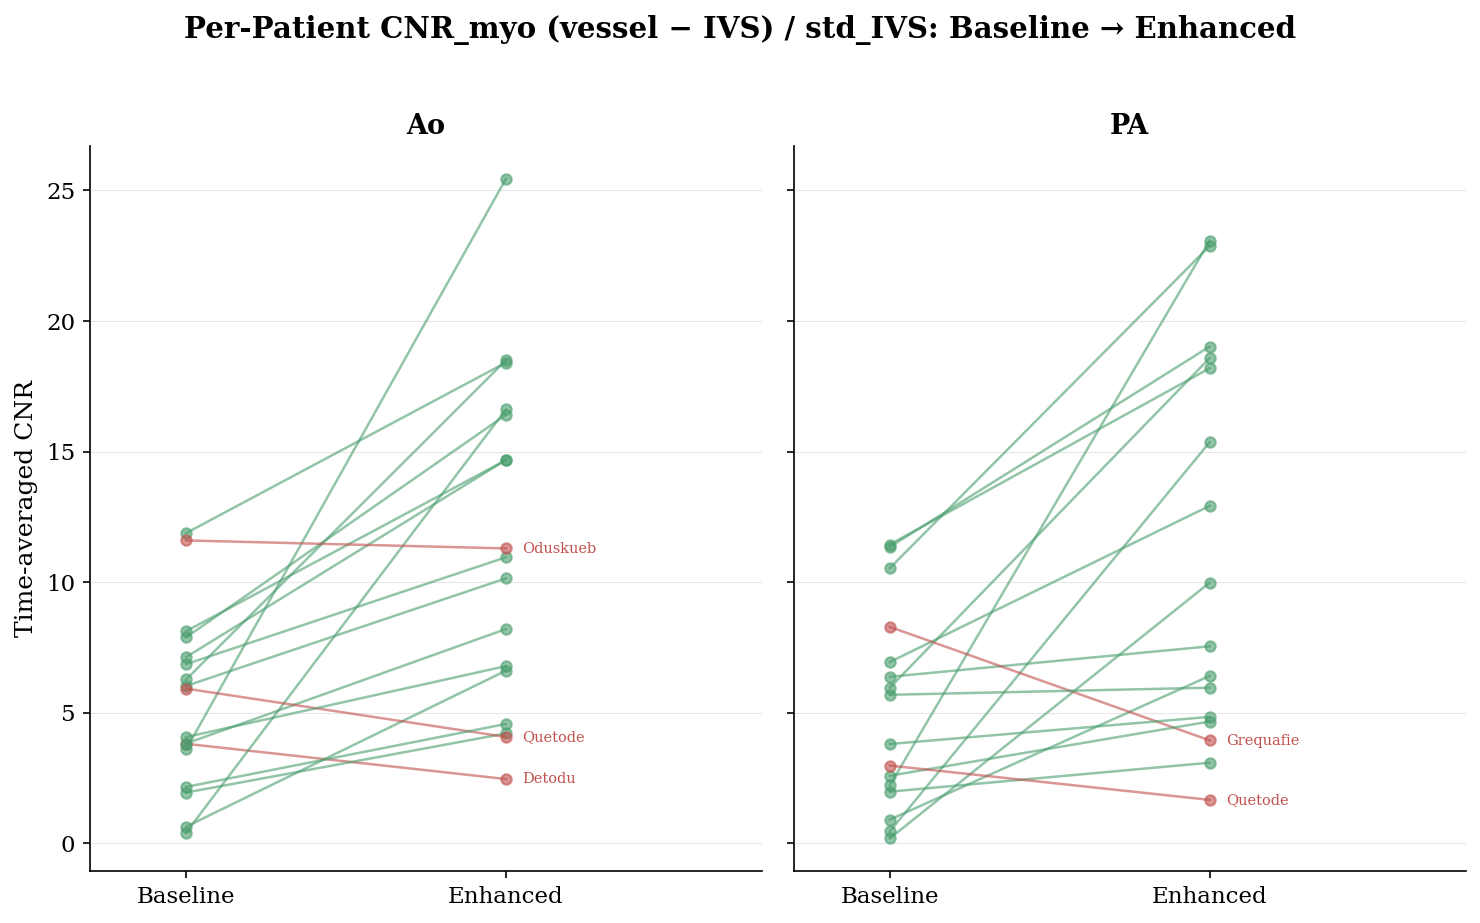

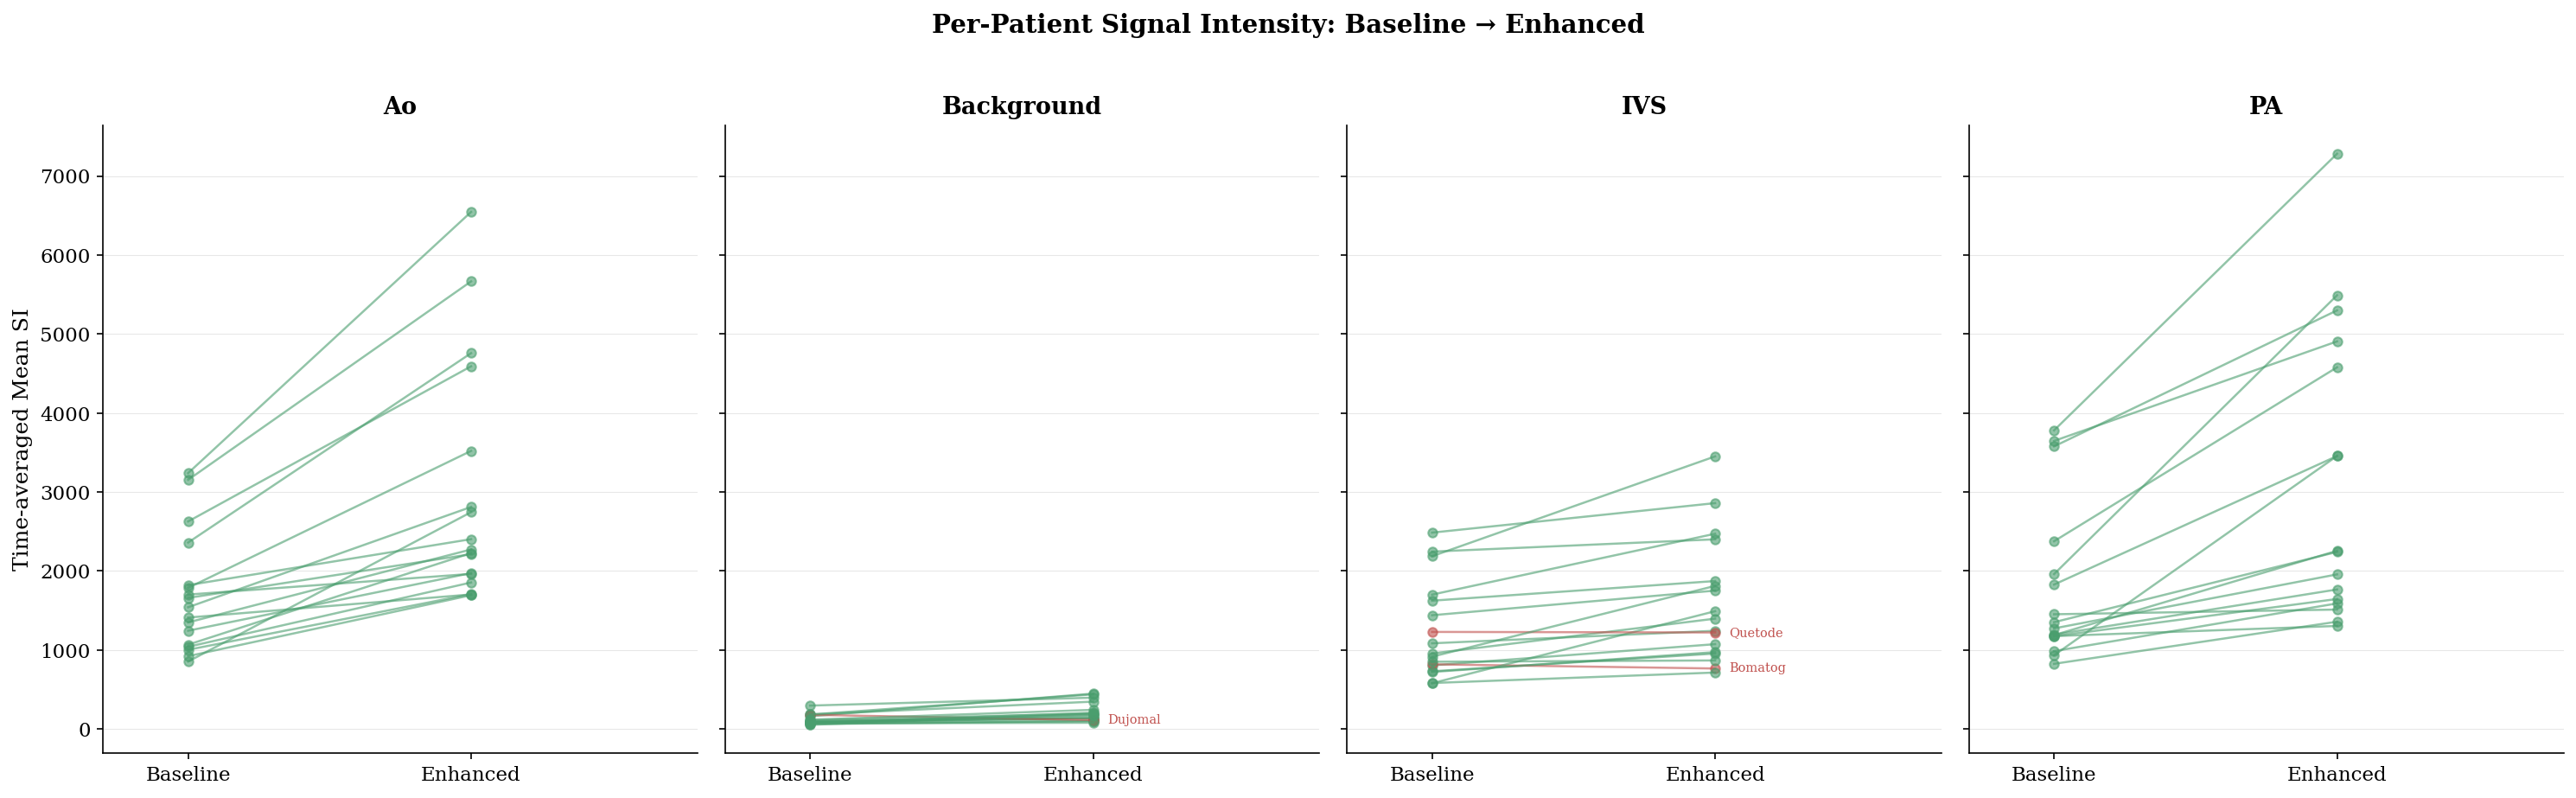

In [138]:
SLOPE_UP = "#4a9e6e"
SLOPE_DOWN = "#c0504d"

def _paired_plot(pivot_df, region_list, ylabel, title, label_col="patient"):
    """Paired slope graph with patient labels."""
    fig, axes = plt.subplots(1, len(region_list), figsize=(5 * len(region_list), 6), sharey=True)
    if len(region_list) == 1:
        axes = [axes]

    for ax, region in zip(axes, region_list):
        pdf = pivot_df.reset_index()
        sub = pdf[pdf["region"] == region].dropna(subset=["normal", "vse"])

        for _, row in sub.iterrows():
            color = SLOPE_UP if row["vse"] >= row["normal"] else SLOPE_DOWN
            ax.plot([0, 1], [row["normal"], row["vse"]], marker="o", color=color,
                    alpha=0.6, linewidth=1.2, markersize=5)
            if row["vse"] < row["normal"]:
                ax.text(1.05, row["vse"], row[label_col], fontsize=7, va="center", color=SLOPE_DOWN)

        ax.set_xticks([0, 1])
        ax.set_xticklabels([LABELS["normal"], LABELS["vse"]])
        ax.set_title(region, fontweight="bold")
        ax.set_xlim(-0.3, 1.8)

    axes[0].set_ylabel(ylabel)
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.02)
    fig.tight_layout()
    plt.show()

# CNR_air paired
_paired_plot(cnr_air_pivot, cnr_regions,
             "Time-averaged CNR", "Per-Patient CNR_air (vessel − air) / std_air: Baseline → Enhanced")

# CNR_myo paired
_paired_plot(cnr_myo_pivot, cnr_regions,
             "Time-averaged CNR", "Per-Patient CNR_myo (vessel − IVS) / std_IVS: Baseline → Enhanced")

# SI paired (all regions, for debugging)
si_pivot = si_avg.pivot_table(index=["patient", "region"], columns="reconstruction", values="si_mean")
si_pivot["vse_minus_normal"] = si_pivot["vse"] - si_pivot["normal"]
_paired_plot(si_pivot, regions,
             "Time-averaged Mean SI", "Per-Patient Signal Intensity: Baseline → Enhanced")

### 1c. Statistical tests

Paired tests (Baseline vs. Enhanced) per region for both CNR definitions.
- **Shapiro-Wilk** on the paired differences (p > 0.05 → normality plausible)
- **Wilcoxon signed-rank** (primary, non-parametric)
- **Paired t-test** (if normality holds)
- **Cohen's d** (effect size: 0.2 small, 0.5 medium, 0.8 large)

In [139]:
stats_results["ttest_sig"] = stats_results["ttest_p"].apply(_sig)
stats_results["normality"] = stats_results["shapiro_p"].apply(lambda p: "yes" if p > 0.05 else "no")

display_cols = ["metric", "region", "n", "normal_mean", "vse_mean", "diff_mean", "diff_std",
                "normality", "shapiro_p", "wilcoxon_p", "wilcoxon_sig", "ttest_p", "ttest_sig", "cohens_d"]
display(stats_results[display_cols].round(4))

,metric,region,n,normal_mean,vse_mean,diff_mean,diff_std,normality,shapiro_p,wilcoxon_p,wilcoxon_sig,ttest_p,ttest_sig,cohens_d
0,CNR_air,Ao,17,52.6775,78.5999,25.9224,37.8177,yes,0.8273,0.0348,*,0.0145,*,0.6855
1,CNR_air,PA,16,54.6921,82.3198,27.6276,41.6657,yes,0.7099,0.0182,*,0.0214,*,0.6631
2,CNR_myo,Ao,17,5.4142,11.4100,5.9957,5.9750,yes,0.0761,0.0002,***,0.0010,**,1.0035
3,CNR_myo,PA,16,5.0988,11.1282,6.0293,6.5348,yes,0.6363,0.0021,**,0.0028,**,0.9226
4,SNR,Ao,17,17.8133,19.7703,1.9570,6.1562,yes,0.0818,0.4038,ns,0.2217,ns,0.3179
5,SNR,PA,16,16.8787,20.8643,3.9856,6.9106,yes,0.5153,0.0507,ns,0.0412,*,0.5767


### 1d. Enhanced / Baseline CNR ratio heatmap

Rows = patients, columns = vessel regions. Color encodes the Enhanced/Baseline
time-averaged CNR ratio (diverging around 1.0: blue = lower, red = higher).

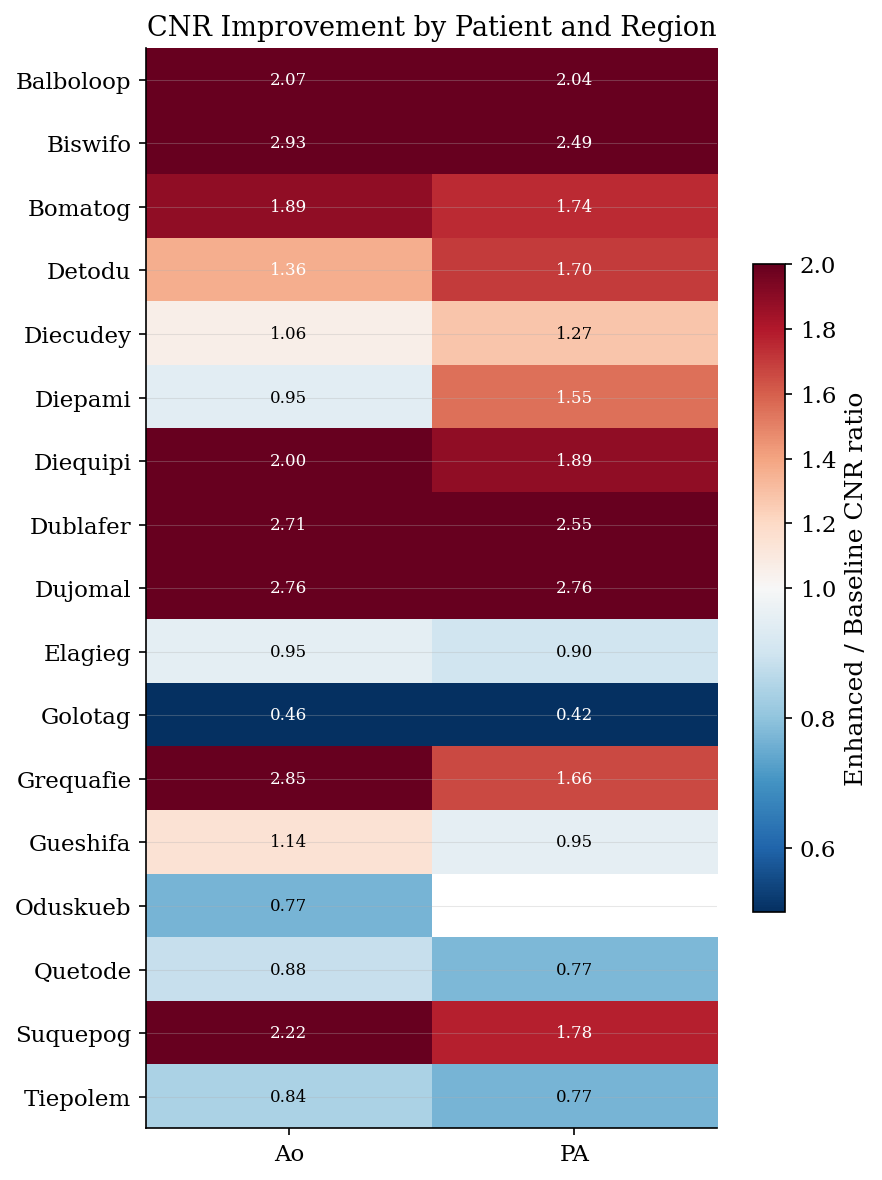

In [140]:
cnr_heatmap_data = (
    cnr_pivot.reset_index()
    .pivot_table(index="patient", columns="region", values="vse_over_normal")
    .sort_index()
)

RATIO_VMIN, RATIO_VMAX = 0.5, 2.0
norm = TwoSlopeNorm(vmin=RATIO_VMIN, vcenter=1.0, vmax=RATIO_VMAX)
clipped = cnr_heatmap_data.clip(RATIO_VMIN, RATIO_VMAX)

fig, ax = plt.subplots(figsize=(6, 8))
im = ax.imshow(clipped.values, cmap="RdBu_r", norm=norm, aspect="auto")

ax.set_xticks(range(len(cnr_heatmap_data.columns)))
ax.set_xticklabels(cnr_heatmap_data.columns)
ax.set_yticks(range(len(cnr_heatmap_data.index)))
ax.set_yticklabels(cnr_heatmap_data.index)

for i in range(len(cnr_heatmap_data.index)):
    for j in range(len(cnr_heatmap_data.columns)):
        val = cnr_heatmap_data.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if abs(val - 1.0) > 0.3 else "black")

fig.colorbar(im, ax=ax, shrink=0.6, label="Enhanced / Baseline CNR ratio")
ax.set_title("CNR Improvement by Patient and Region", fontsize=13)
fig.tight_layout()
plt.show()

---

# 2. Quality check: VSE preserves SNR

Enhancement is not expected to increase SNR — the goal is to confirm that the
Enhanced reconstruction does not degrade signal-to-noise ratio relative to Baseline.

### 2a. SNR distribution: Baseline vs. Enhanced by region

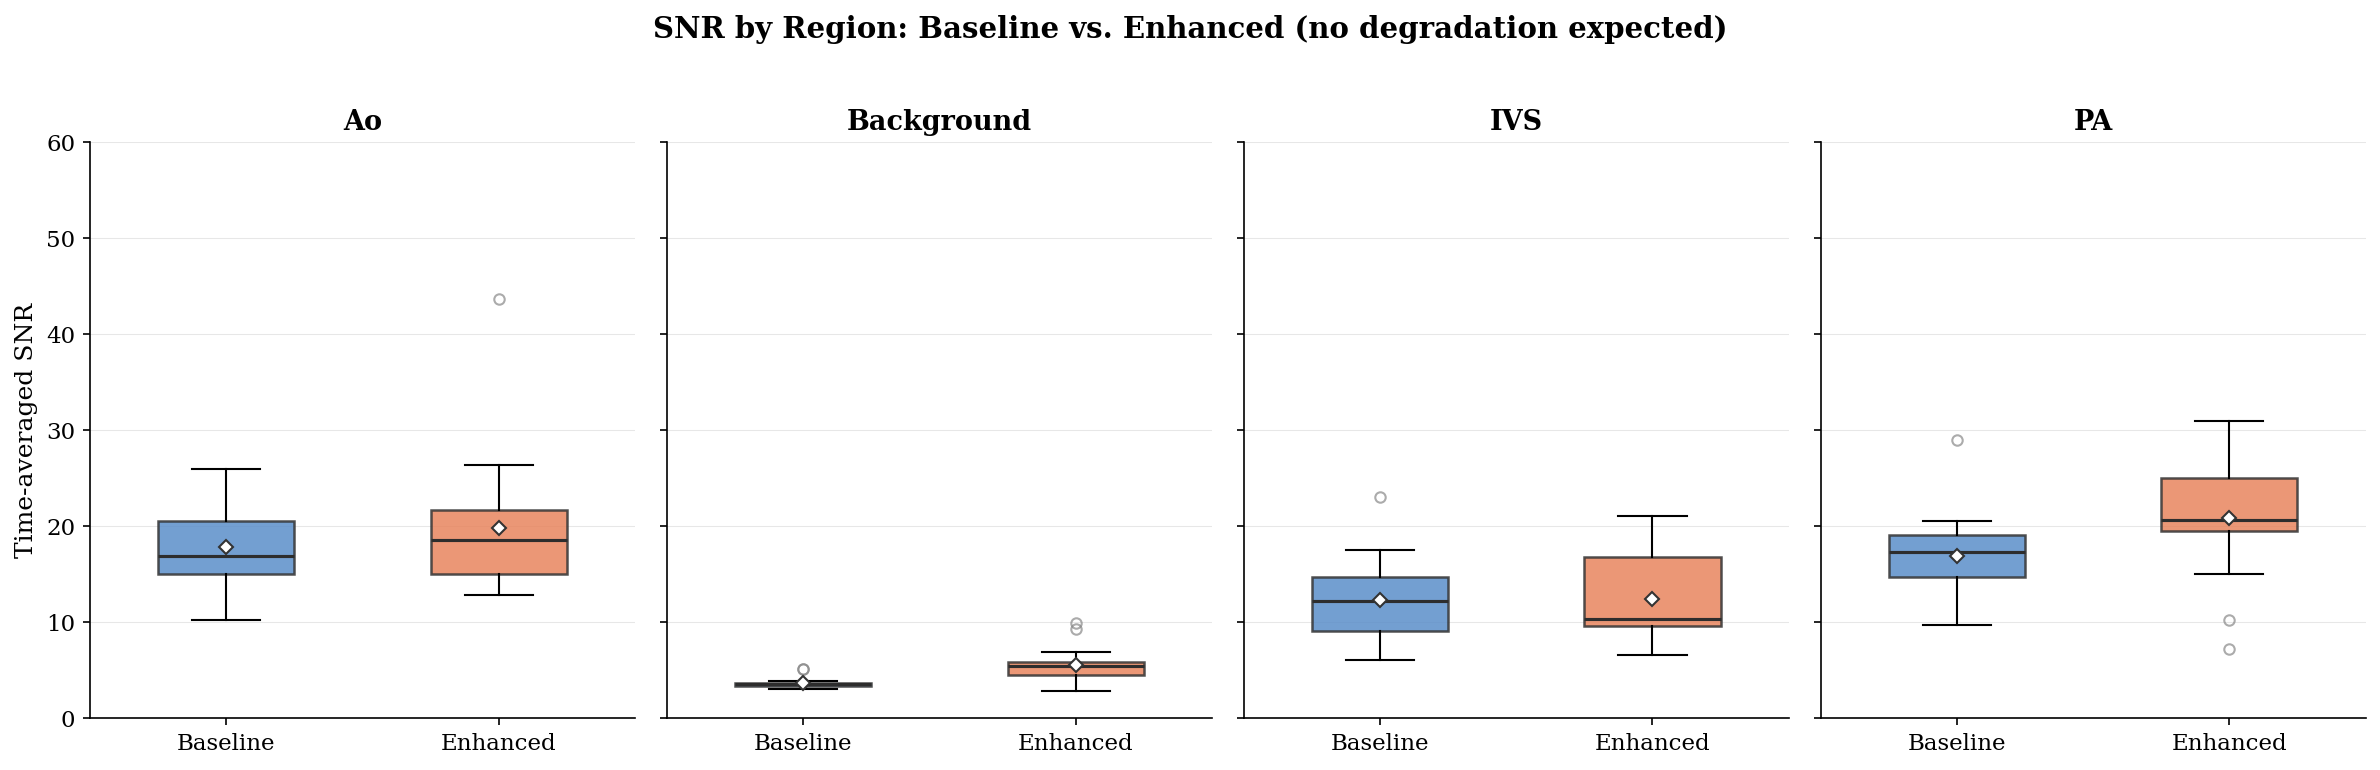

In [141]:
SNR_YLIM = (0, 60)

fig, axes = plt.subplots(1, len(regions), figsize=(4 * len(regions), 5), sharey=True)

for ax, region in zip(axes, regions):
    subset = snr_avg[snr_avg["region"] == region]
    normal = subset[subset["reconstruction"] == "normal"]["snr_mean"]
    vse = subset[subset["reconstruction"] == "vse"]["snr_mean"]

    bp = ax.boxplot([normal, vse], positions=[0, 1], widths=0.5, **BOXPLOT_KW)
    color_boxes(bp, [COLORS["normal"], COLORS["vse"]])

    ax.set_xticks([0, 1])
    ax.set_xticklabels([LABELS["normal"], LABELS["vse"]])
    ax.set_title(region, fontweight="bold")
    ax.set_ylim(SNR_YLIM)

    n_clipped = int((normal > SNR_YLIM[1]).sum() + (vse > SNR_YLIM[1]).sum())
    if n_clipped:
        ax.text(0.95, 0.95, f"{n_clipped} pts clipped",
                transform=ax.transAxes, ha="right", va="top", fontsize=8, color="gray")

axes[0].set_ylabel("Time-averaged SNR")
fig.suptitle("SNR by Region: Baseline vs. Enhanced (no degradation expected)",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

### 2b. Paired patient-level SNR: Baseline → Enhanced

Each line connects one patient's time-averaged SNR under Baseline (left) to Enhanced (right).
Near-horizontal lines indicate SNR is preserved.

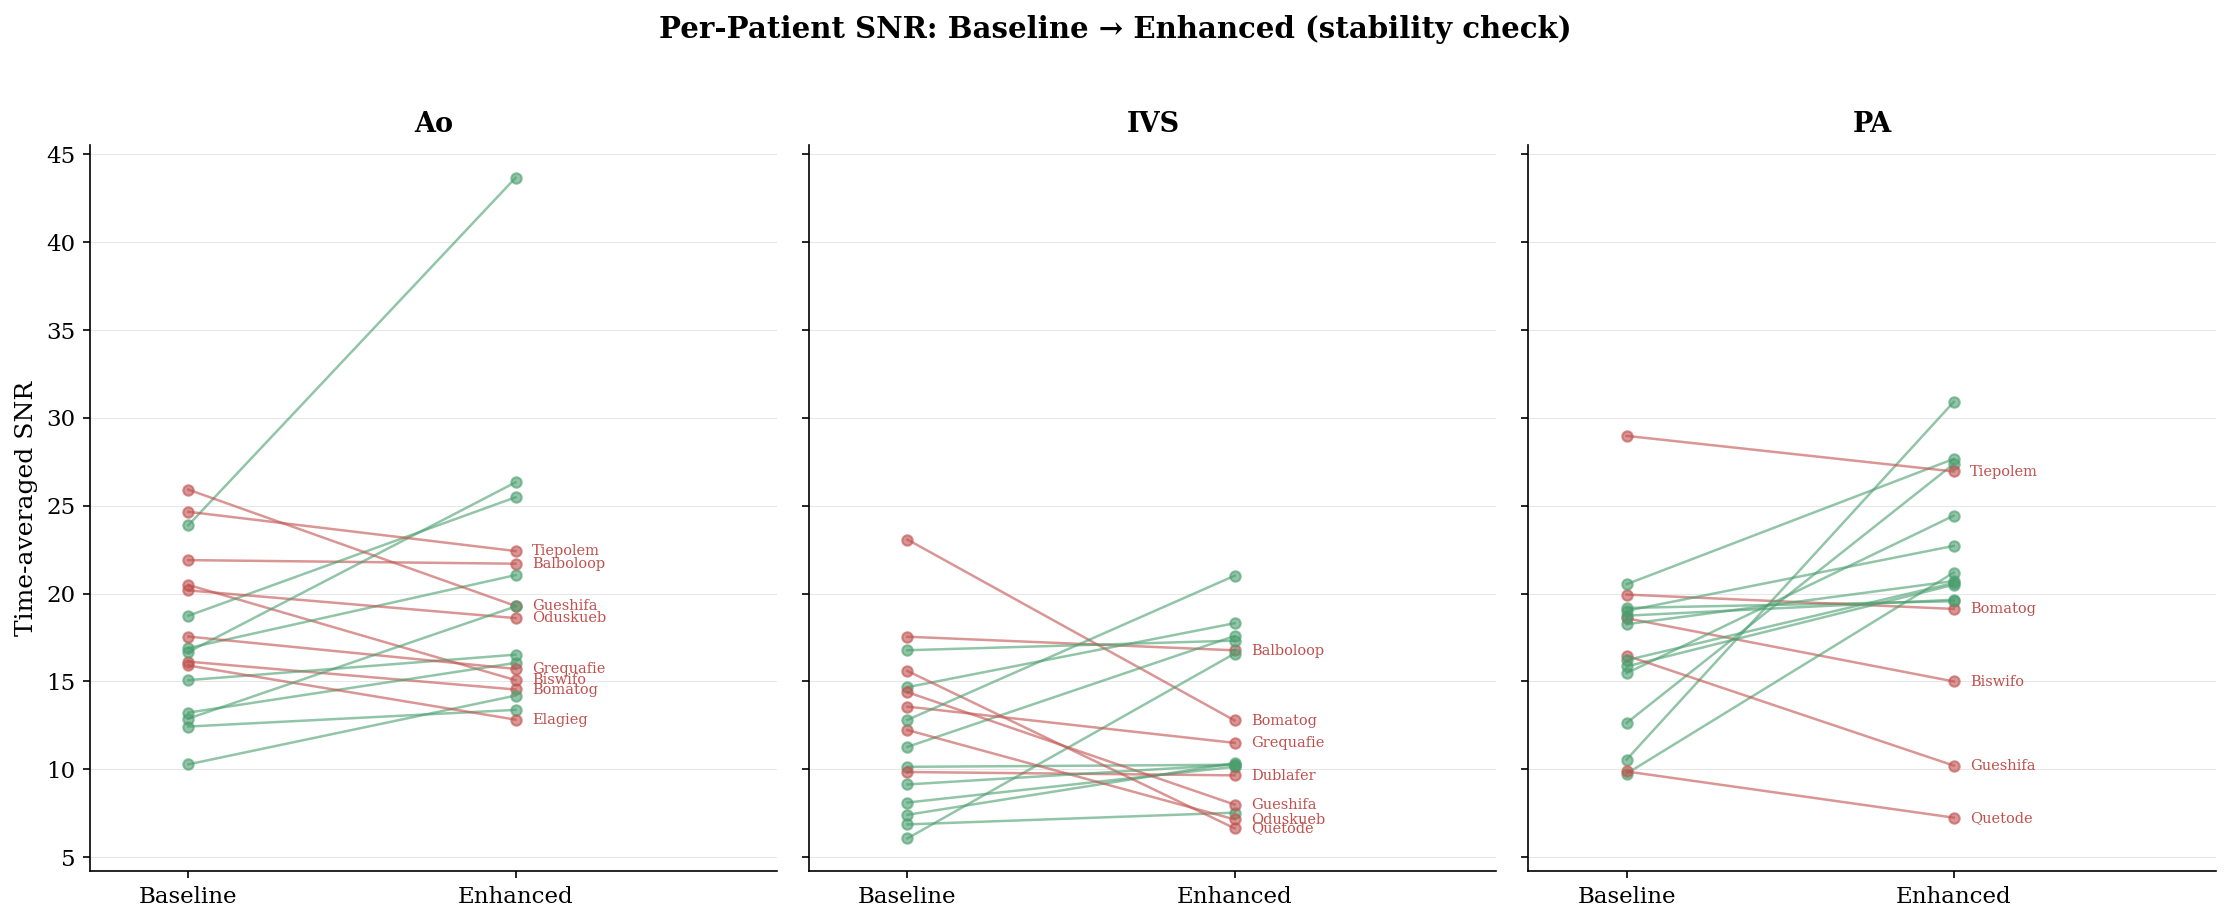

In [142]:
_paired_plot(snr_pivot, vessel_regions,
             "Time-averaged SNR", "Per-Patient SNR: Baseline → Enhanced (stability check)")

### 2c. SNR summary statistics & Enhanced/Baseline ratio

In [143]:
snr_summary = (
    snr_avg.groupby(["region", "reconstruction"])["snr_mean"]
    .agg(["mean", "std", "min", "max", "count"])
    .round(2)
)
print("Time-averaged SNR summary (across patients):")
display(snr_summary)

snr_ratio_by_region = (
    snr_pivot.reset_index()
    .groupby("region")["vse_over_normal"]
    .agg(["mean", "std"])
    .round(3)
    .rename(columns={"mean": "ratio_mean", "std": "ratio_std"})
)
print("\nEnhanced/Baseline SNR ratio (≈1.0 indicates preservation):")
display(snr_ratio_by_region)

Time-averaged SNR summary (across patients):


mean   std    min    max  count
region     reconstruction                                  
Ao         normal          17.81  4.52  10.28  25.91     17
           vse             19.77  7.37  12.83  43.65     17
Background normal           3.68  0.61   3.04   5.18     17
           vse              5.54  1.88   2.86   9.96     17
IVS        normal          12.33  4.46   6.07  23.07     17
           vse             12.46  4.52   6.65  21.01     17
PA         normal          16.88  4.82   9.76  28.97     16
           vse             20.86  6.23   7.25  30.90     16


Enhanced/Baseline SNR ratio (≈1.0 indicates preservation):


,ratio_mean,ratio_std
region,,
Ao,1.128,0.315
Background,1.549,0.593
IVS,1.117,0.543
PA,1.325,0.616


---

# 3. Supporting analyses

### 3a. Time curves over the cardiac cycle

Mean SI, SNR, and CNR over the 20 cardiac timepoints, Baseline vs. Enhanced, with
median and IQR shading. All subplots within each metric share the same y-axis
scale for direct comparison across regions.

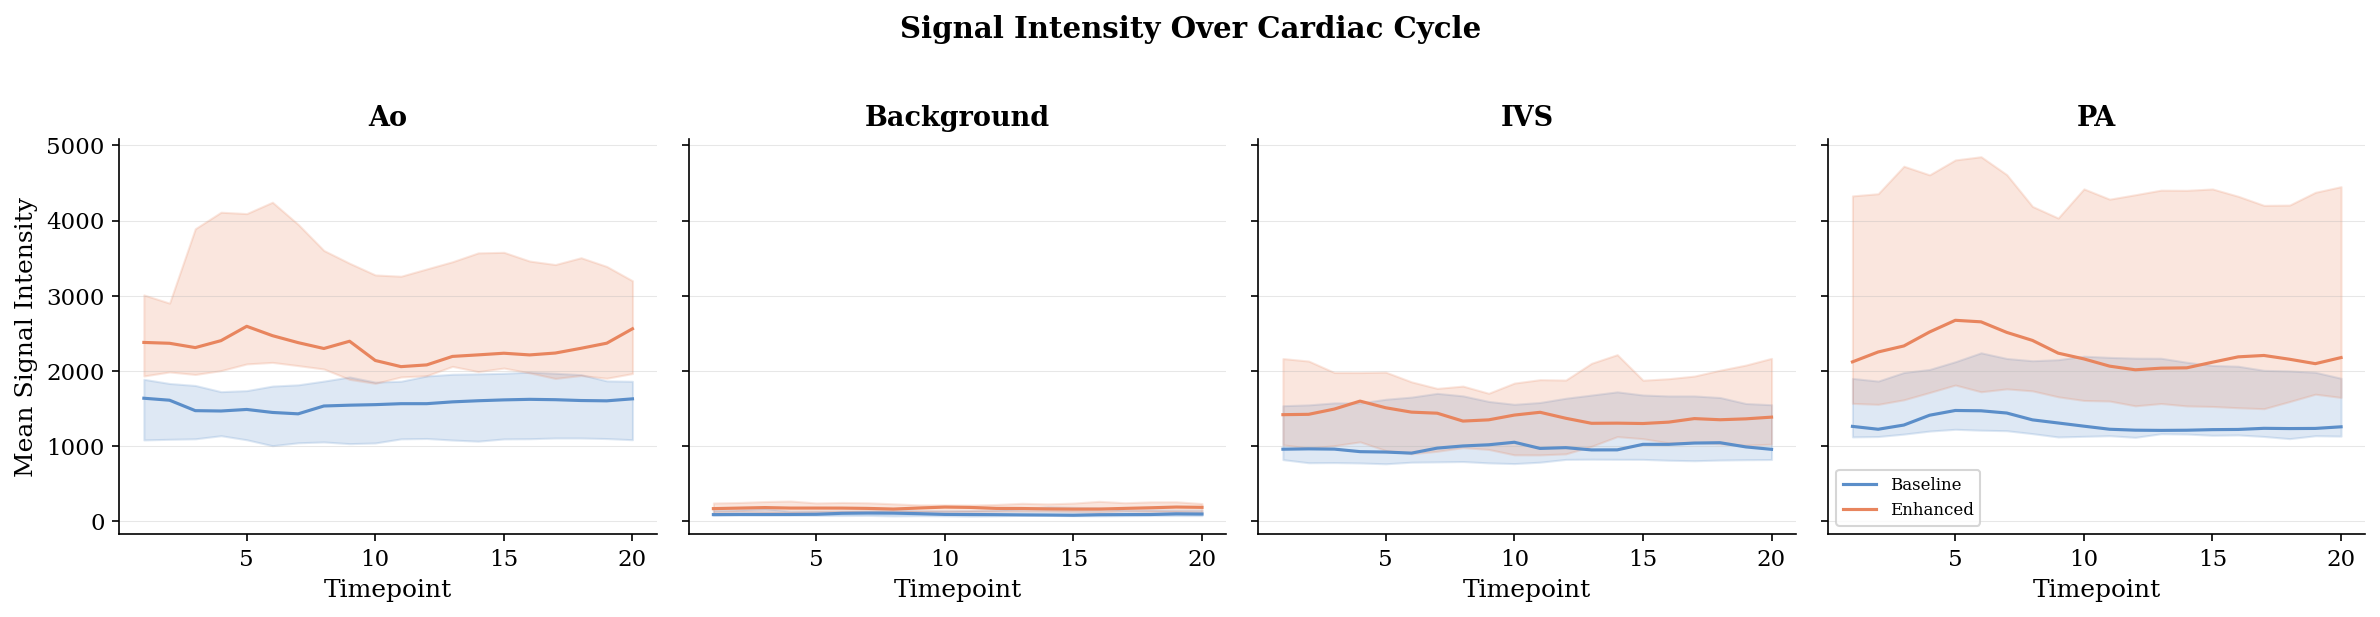

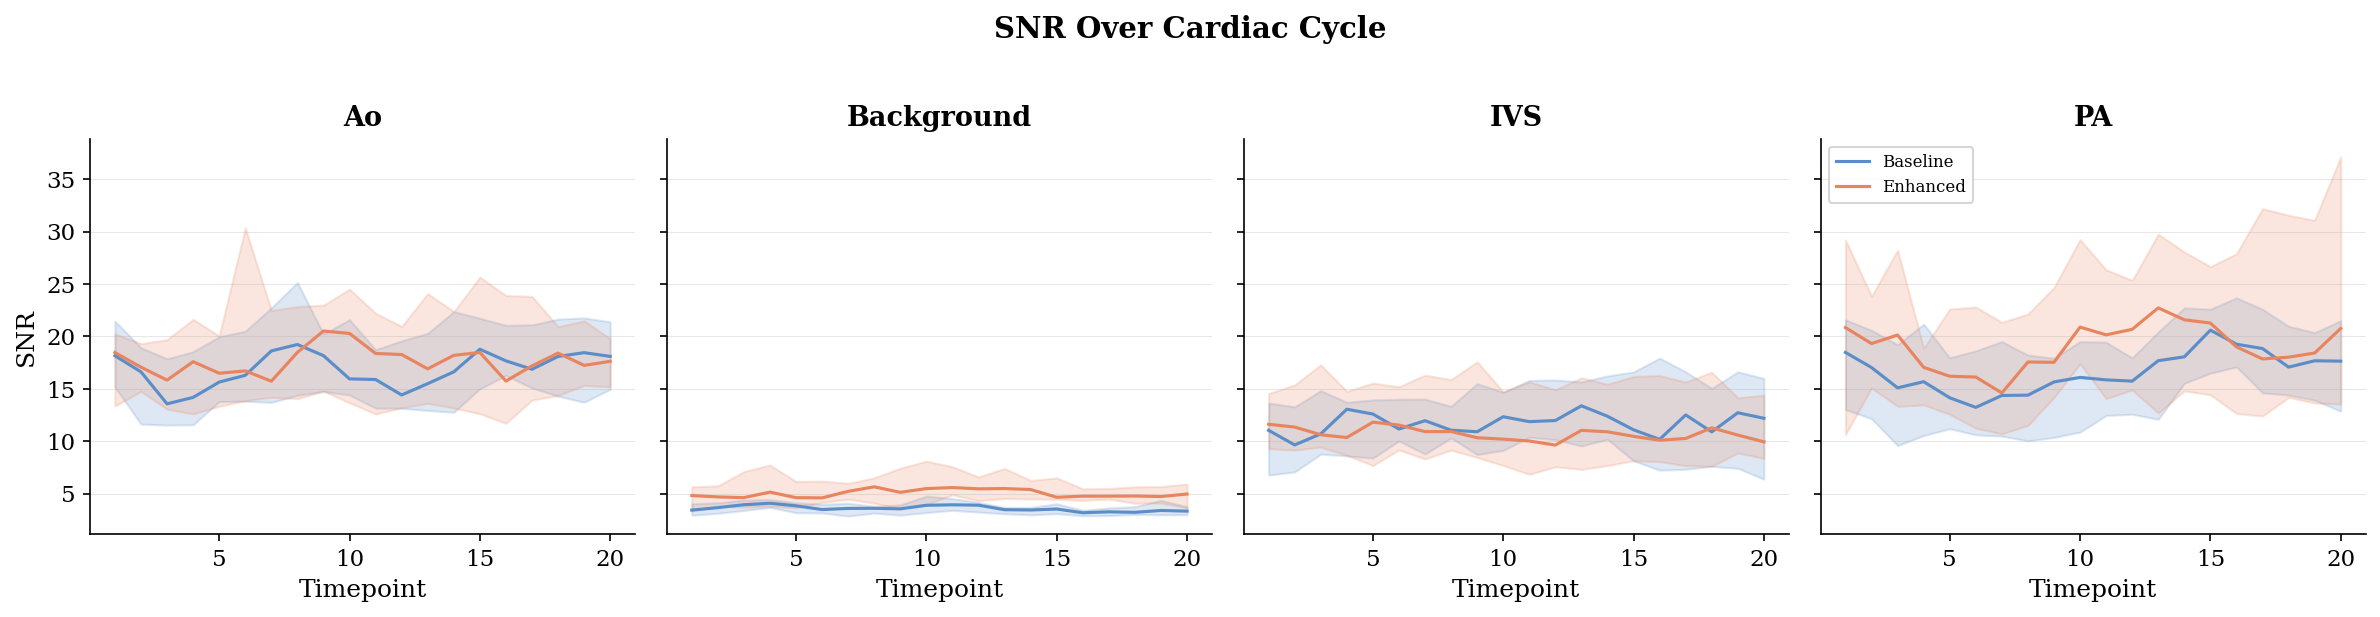

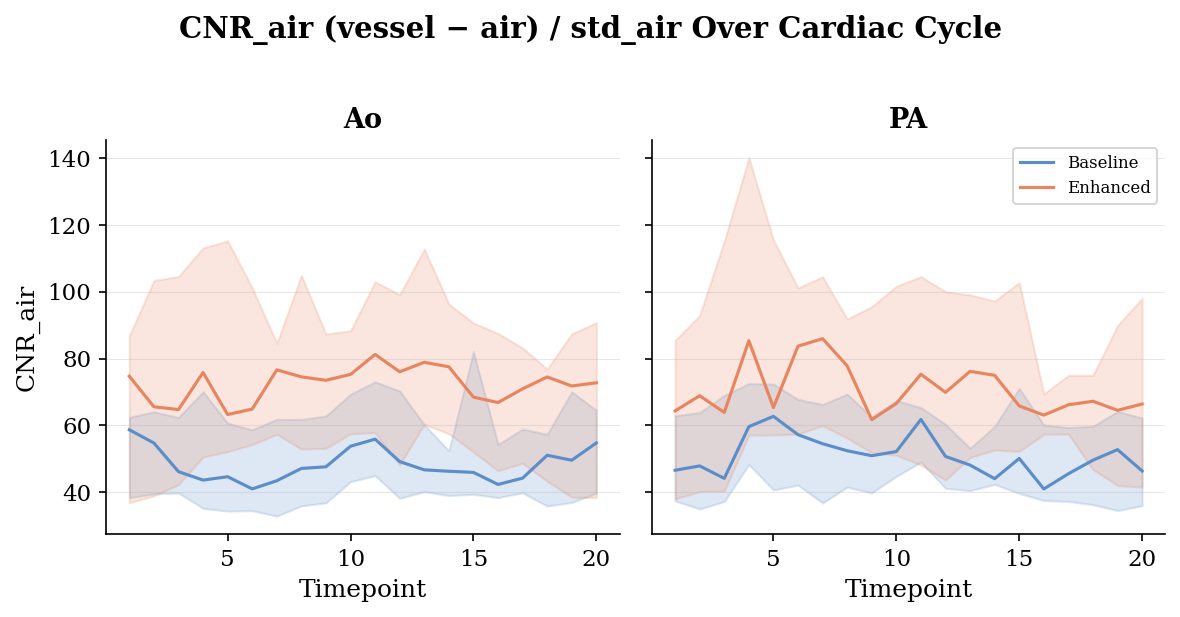

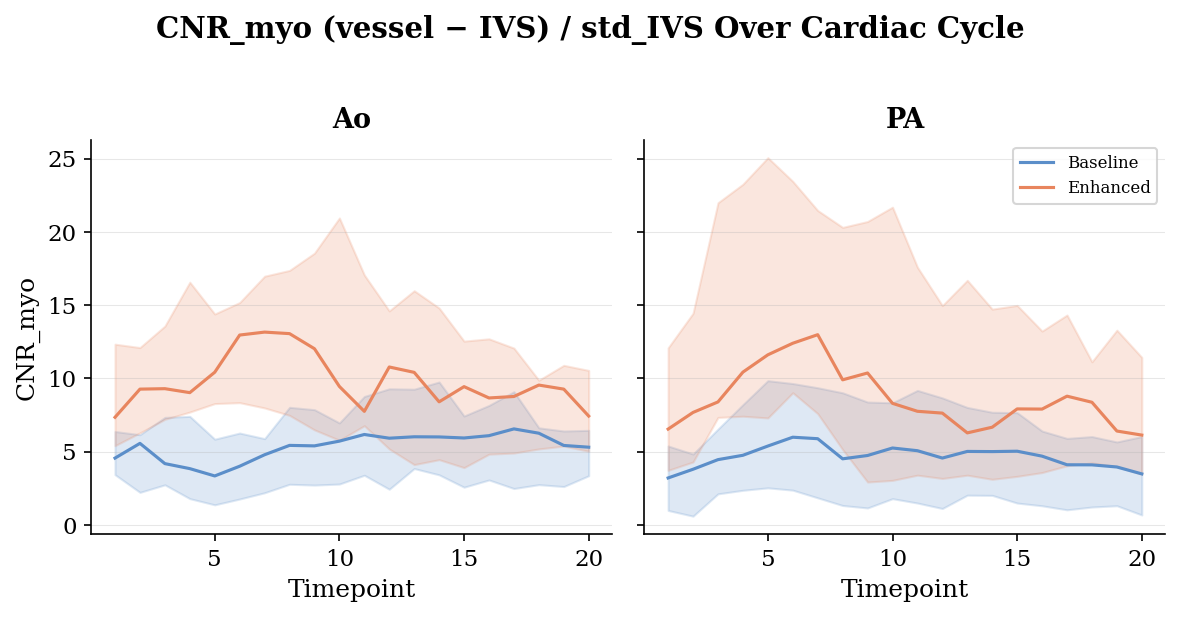

In [144]:
def _time_curve(ax, sub_data, value_col):
    """Plot Baseline vs Enhanced time curves with median and IQR shading."""
    for recon, color in COLORS.items():
        sub = sub_data[sub_data["reconstruction"] == recon]
        grouped = sub.groupby("timepoint")[value_col]
        med = grouped.median()
        q1 = grouped.quantile(0.25)
        q3 = grouped.quantile(0.75)
        ax.plot(med.index, med.values, color=color, label=LABELS[recon], linewidth=1.5)
        ax.fill_between(med.index, q1.values, q3.values, color=color, alpha=0.2)

# --- Signal Intensity ---
fig, axes = plt.subplots(1, len(regions), figsize=(4 * len(regions), 4), sharey=True)
for ax, region in zip(axes, regions):
    _time_curve(ax, data[data["region"] == region], "mean")
    ax.set_title(region, fontweight="bold")
    ax.set_xlabel("Timepoint")
axes[0].set_ylabel("Mean Signal Intensity")
axes[-1].legend(fontsize=8)
fig.suptitle("Signal Intensity Over Cardiac Cycle", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

# --- SNR ---
fig, axes = plt.subplots(1, len(regions), figsize=(4 * len(regions), 4), sharey=True)
for ax, region in zip(axes, regions):
    _time_curve(ax, data[data["region"] == region], "snr")
    ax.set_title(region, fontweight="bold")
    ax.set_xlabel("Timepoint")
axes[0].set_ylabel("SNR")
axes[-1].legend(fontsize=8)
fig.suptitle("SNR Over Cardiac Cycle", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

# --- CNR_air (Ao + PA only) ---
fig, axes = plt.subplots(1, len(cnr_regions), figsize=(4 * len(cnr_regions), 4), sharey=True)
for ax, region in zip(axes, cnr_regions):
    _time_curve(ax, cnr_air_data[cnr_air_data["region"] == region], "cnr")
    ax.set_title(region, fontweight="bold")
    ax.set_xlabel("Timepoint")
axes[0].set_ylabel("CNR_air")
axes[-1].legend(fontsize=8)
fig.suptitle("CNR_air (vessel − air) / std_air Over Cardiac Cycle",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

# --- CNR_myo (Ao + PA only) ---
fig, axes = plt.subplots(1, len(cnr_regions), figsize=(4 * len(cnr_regions), 4), sharey=True)
for ax, region in zip(axes, cnr_regions):
    _time_curve(ax, cnr_myo_data[cnr_myo_data["region"] == region], "cnr")
    ax.set_title(region, fontweight="bold")
    ax.set_xlabel("Timepoint")
axes[0].set_ylabel("CNR_myo")
axes[-1].legend(fontsize=8)
fig.suptitle("CNR_myo (vessel − IVS) / std_IVS Over Cardiac Cycle",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

### 3b. Grouped summary bar plots

Mean SI, SNR, and CNR grouped by region with Baseline vs. Enhanced bars and SD error bars.

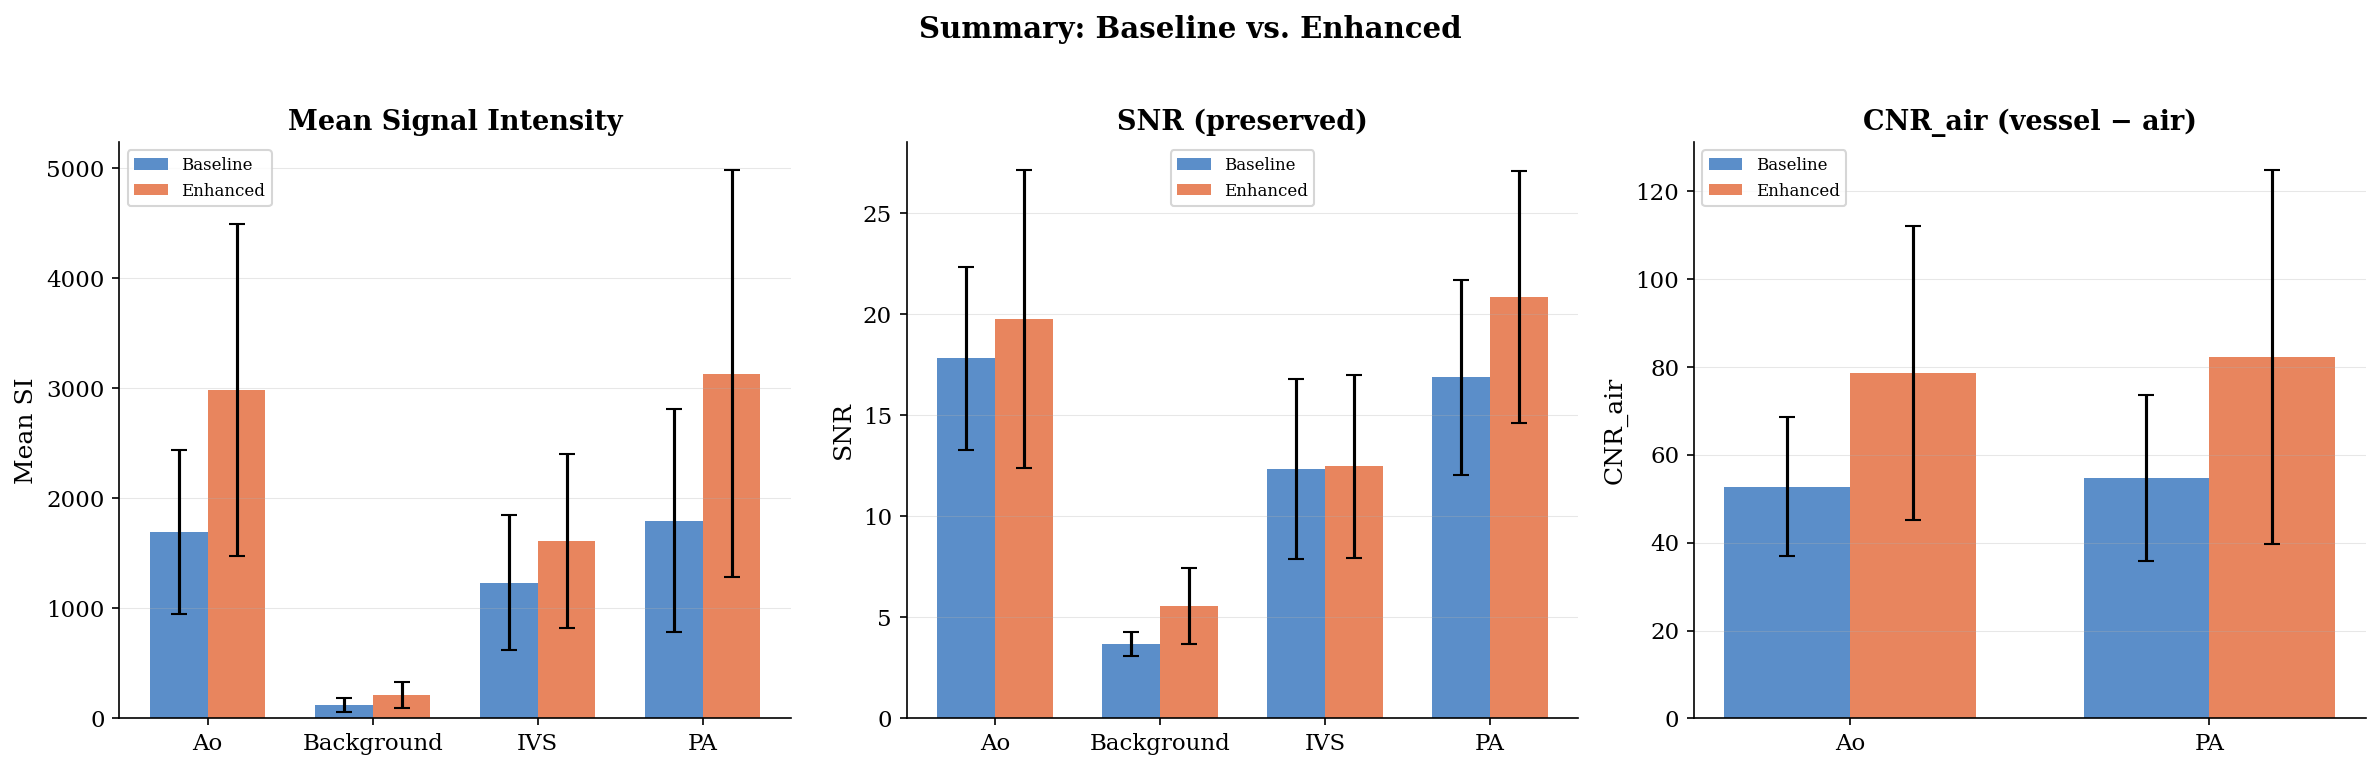

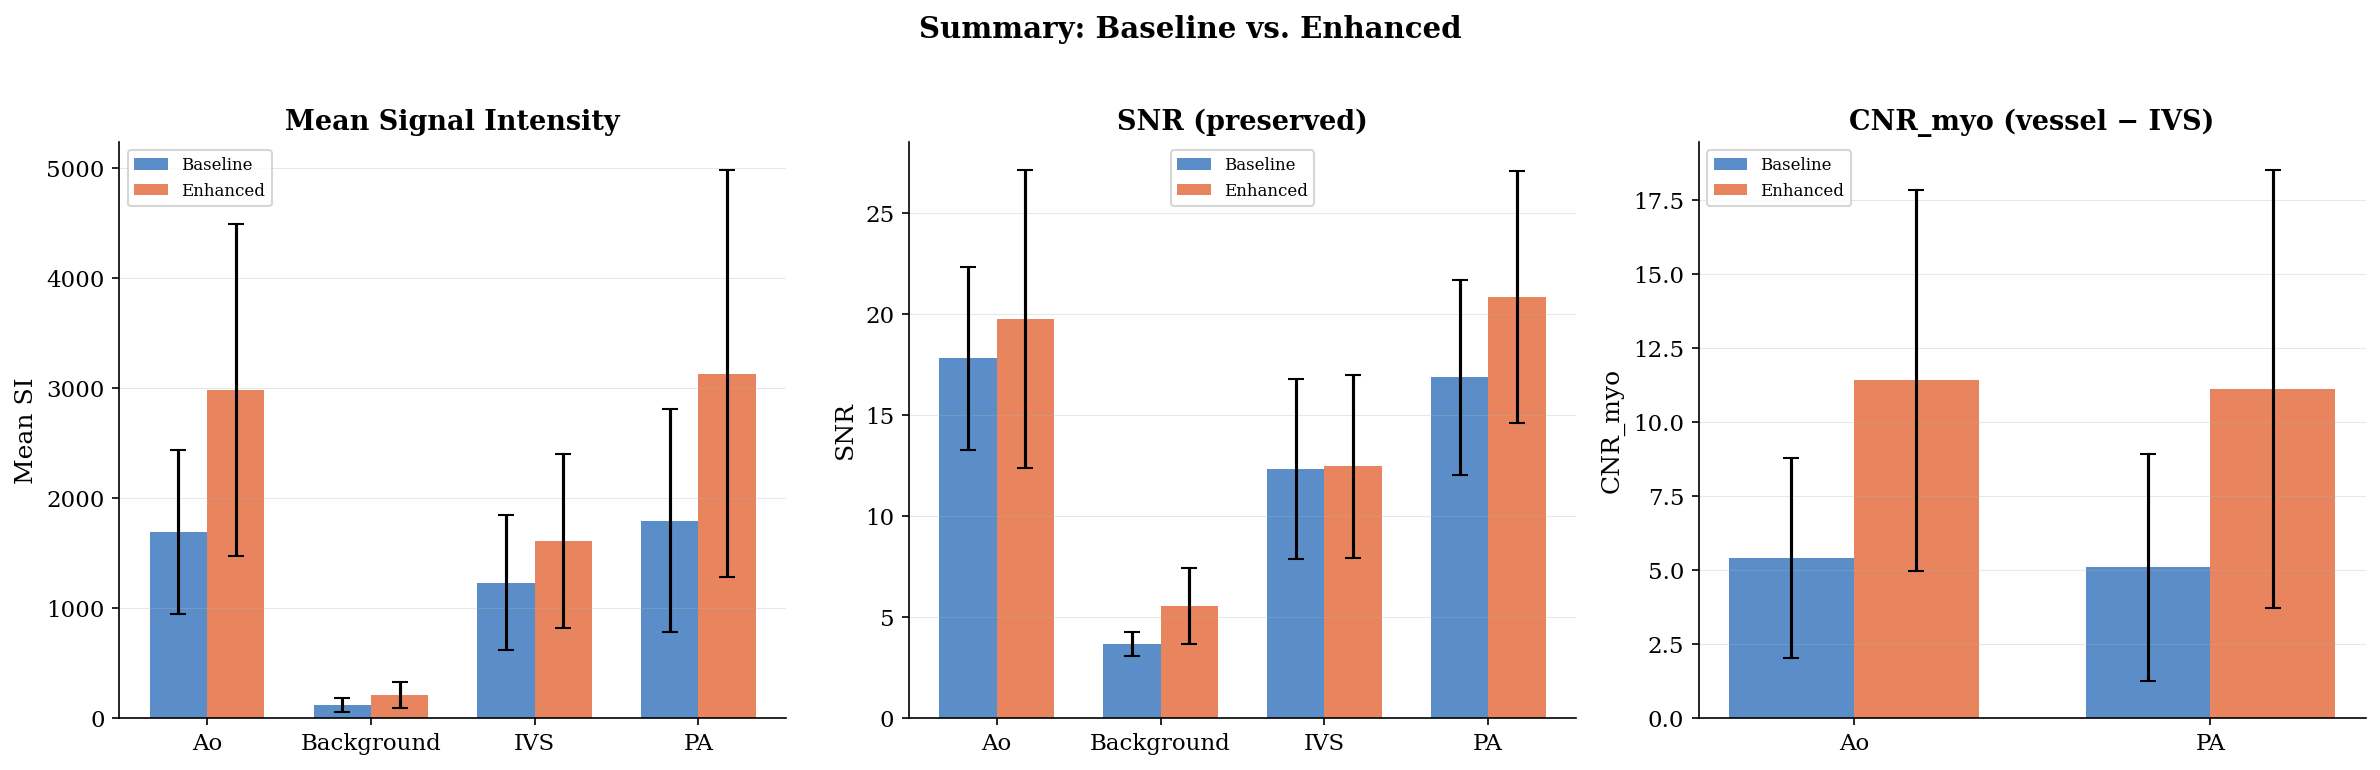

In [145]:
def _bar_data(df, value_col, region_list):
    """Return (means_normal, sds_normal, means_vse, sds_vse) for each region."""
    mn, sn, mv, sv = [], [], [], []
    for region in region_list:
        for recon, m_list, s_list in [("normal", mn, sn), ("vse", mv, sv)]:
            vals = df[(df["region"] == region) & (df["reconstruction"] == recon)][value_col]
            m_list.append(vals.mean())
            s_list.append(vals.std())
    return mn, sn, mv, sv

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
bar_width = 0.35

# Mean SI (all regions)
ax = axes[0]
mn, sn, mv, sv = _bar_data(si_avg, "si_mean", regions)
x = np.arange(len(regions))
ax.bar(x - bar_width / 2, mn, bar_width, yerr=sn, capsize=4, color=COLORS["normal"], label=LABELS["normal"])
ax.bar(x + bar_width / 2, mv, bar_width, yerr=sv, capsize=4, color=COLORS["vse"], label=LABELS["vse"])
ax.set_xticks(x)
ax.set_xticklabels(regions)
ax.set_ylabel("Mean SI")
ax.set_title("Mean Signal Intensity", fontweight="bold")
ax.legend(fontsize=8)

# SNR (all regions)
ax = axes[1]
mn, sn, mv, sv = _bar_data(snr_avg, "snr_mean", regions)
ax.bar(x - bar_width / 2, mn, bar_width, yerr=sn, capsize=4, color=COLORS["normal"], label=LABELS["normal"])
ax.bar(x + bar_width / 2, mv, bar_width, yerr=sv, capsize=4, color=COLORS["vse"], label=LABELS["vse"])
ax.set_xticks(x)
ax.set_xticklabels(regions)
ax.set_ylabel("SNR")
ax.set_title("SNR (preserved)", fontweight="bold")
ax.legend(fontsize=8)

# CNR_air (Ao + PA only)
ax = axes[2]
xv = np.arange(len(cnr_regions))
mn, sn, mv, sv = _bar_data(cnr_air_avg, "cnr_mean", cnr_regions)
ax.bar(xv - bar_width / 2, mn, bar_width, yerr=sn, capsize=4, color=COLORS["normal"], label=LABELS["normal"])
ax.bar(xv + bar_width / 2, mv, bar_width, yerr=sv, capsize=4, color=COLORS["vse"], label=LABELS["vse"])
ax.set_xticks(xv)
ax.set_xticklabels(cnr_regions)
ax.set_ylabel("CNR_air")
ax.set_title("CNR_air (vessel − air)", fontweight="bold")
ax.legend(fontsize=8)

fig.suptitle("Summary: Baseline vs. Enhanced", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

# Same layout but with CNR_myo
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
mn, sn, mv, sv = _bar_data(si_avg, "si_mean", regions)
ax.bar(x - bar_width / 2, mn, bar_width, yerr=sn, capsize=4, color=COLORS["normal"], label=LABELS["normal"])
ax.bar(x + bar_width / 2, mv, bar_width, yerr=sv, capsize=4, color=COLORS["vse"], label=LABELS["vse"])
ax.set_xticks(x)
ax.set_xticklabels(regions)
ax.set_ylabel("Mean SI")
ax.set_title("Mean Signal Intensity", fontweight="bold")
ax.legend(fontsize=8)

ax = axes[1]
mn, sn, mv, sv = _bar_data(snr_avg, "snr_mean", regions)
ax.bar(x - bar_width / 2, mn, bar_width, yerr=sn, capsize=4, color=COLORS["normal"], label=LABELS["normal"])
ax.bar(x + bar_width / 2, mv, bar_width, yerr=sv, capsize=4, color=COLORS["vse"], label=LABELS["vse"])
ax.set_xticks(x)
ax.set_xticklabels(regions)
ax.set_ylabel("SNR")
ax.set_title("SNR (preserved)", fontweight="bold")
ax.legend(fontsize=8)

ax = axes[2]
mn, sn, mv, sv = _bar_data(cnr_myo_avg, "cnr_mean", cnr_regions)
ax.bar(xv - bar_width / 2, mn, bar_width, yerr=sn, capsize=4, color=COLORS["normal"], label=LABELS["normal"])
ax.bar(xv + bar_width / 2, mv, bar_width, yerr=sv, capsize=4, color=COLORS["vse"], label=LABELS["vse"])
ax.set_xticks(xv)
ax.set_xticklabels(cnr_regions)
ax.set_ylabel("CNR_myo")
ax.set_title("CNR_myo (vessel − IVS)", fontweight="bold")
ax.legend(fontsize=8)

fig.suptitle("Summary: Baseline vs. Enhanced", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

### 3c. Enhanced / Baseline SNR ratio heatmap

Rows = patients, columns = vessel regions. Values near 1.0 confirm SNR preservation.

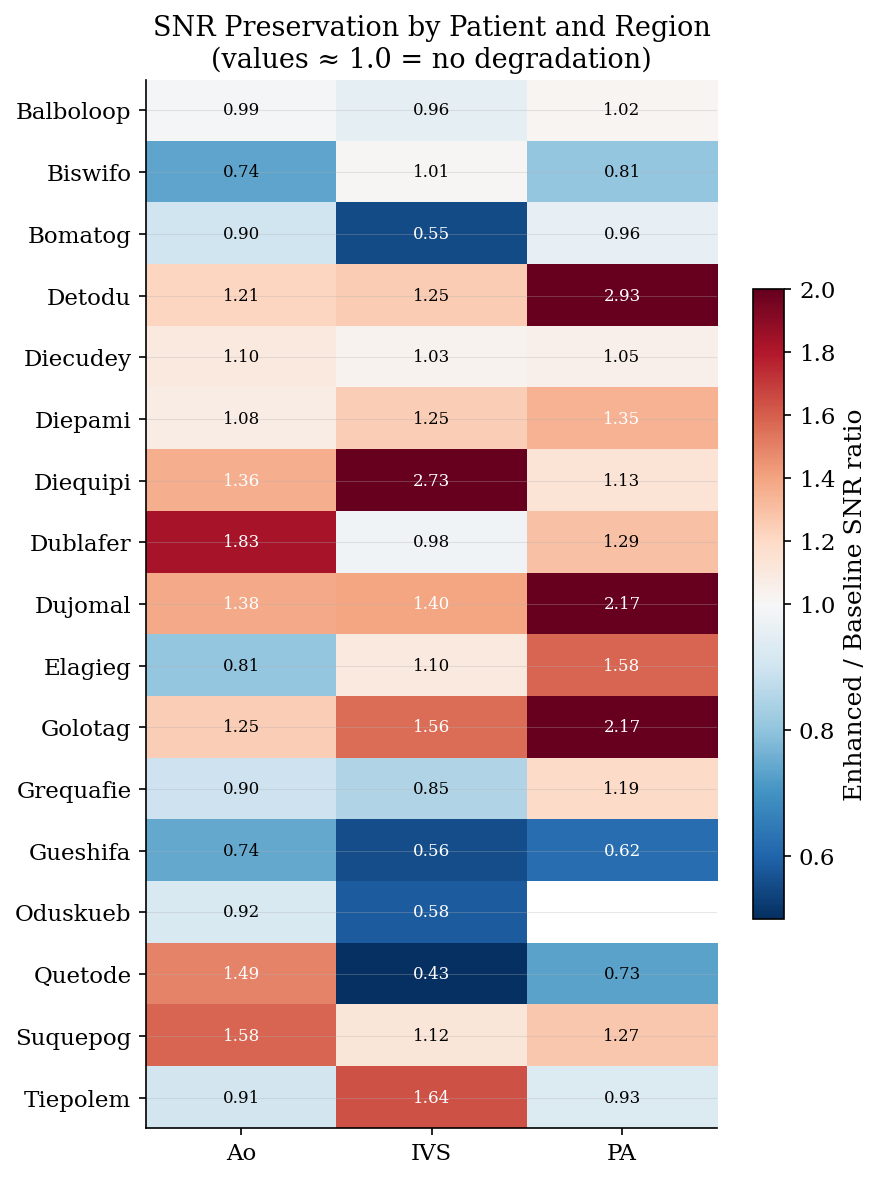

In [146]:
snr_heatmap_data = (
    snr_pivot.reset_index()
    .query("region != 'Background'")
    .pivot_table(index="patient", columns="region", values="vse_over_normal")
    .sort_index()
)

RATIO_VMIN, RATIO_VMAX = 0.5, 2.0
norm = TwoSlopeNorm(vmin=RATIO_VMIN, vcenter=1.0, vmax=RATIO_VMAX)
clipped = snr_heatmap_data.clip(RATIO_VMIN, RATIO_VMAX)

fig, ax = plt.subplots(figsize=(6, 8))
im = ax.imshow(clipped.values, cmap="RdBu_r", norm=norm, aspect="auto")

ax.set_xticks(range(len(snr_heatmap_data.columns)))
ax.set_xticklabels(snr_heatmap_data.columns)
ax.set_yticks(range(len(snr_heatmap_data.index)))
ax.set_yticklabels(snr_heatmap_data.index)

for i in range(len(snr_heatmap_data.index)):
    for j in range(len(snr_heatmap_data.columns)):
        val = snr_heatmap_data.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if abs(val - 1.0) > 0.3 else "black")

fig.colorbar(im, ax=ax, shrink=0.6, label="Enhanced / Baseline SNR ratio")
ax.set_title("SNR Preservation by Patient and Region\n(values ≈ 1.0 = no degradation)", fontsize=13)
fig.tight_layout()
plt.show()